# Volcanoes  latitude and longitude

### Viktoria Ivanova - 7MI3400799

In this assignment we will investigate whether clustering can be used to identify volcanoes that lie on the same
tectonic plate boundary.

### Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans

Retrieve the data by using Wikidata Query Service with the following query:

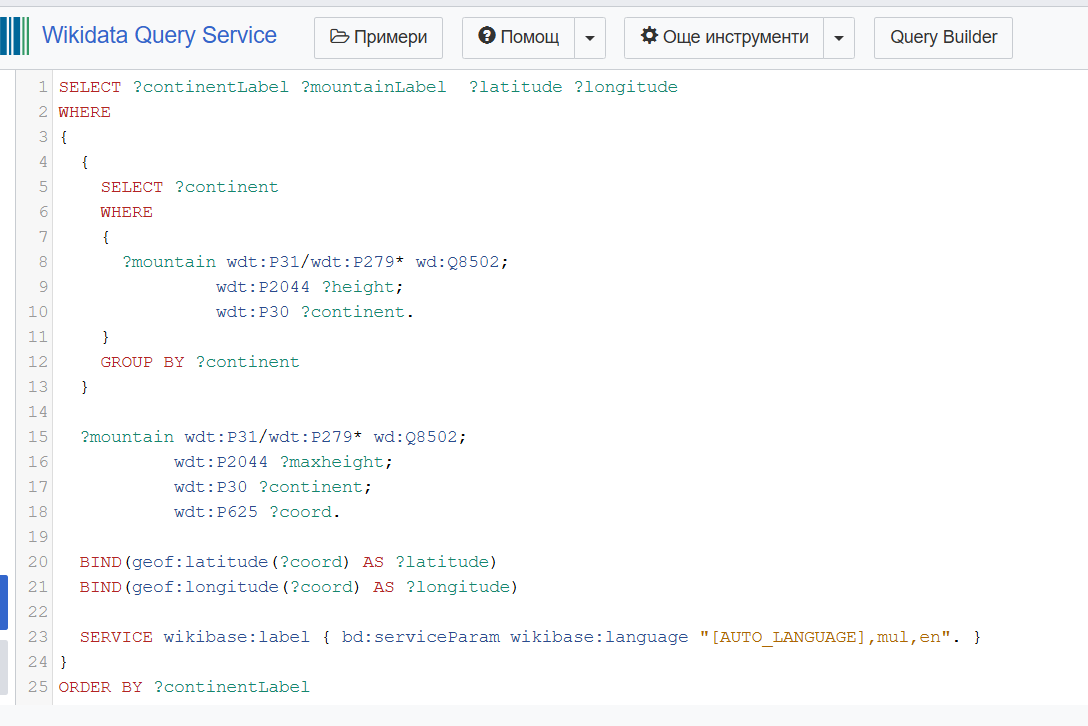

In [4]:
volcanoes_df = pd.read_csv("volcanoes.csv")
volcanoes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4730 entries, 0 to 4729
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   continentLabel  4730 non-null   object 
 1   mountainLabel   4730 non-null   object 
 2   latitude        4730 non-null   float64
 3   longitude       4730 non-null   float64
dtypes: float64(2), object(2)
memory usage: 147.9+ KB


We will use two well known methods for clustering the volcanos, DBSCAN and KMeans and will check if they give good enough results to conclude whether clustering can be used to identify volcanoes that lie on the same tectonic plate boundary

Number of clusters: 8


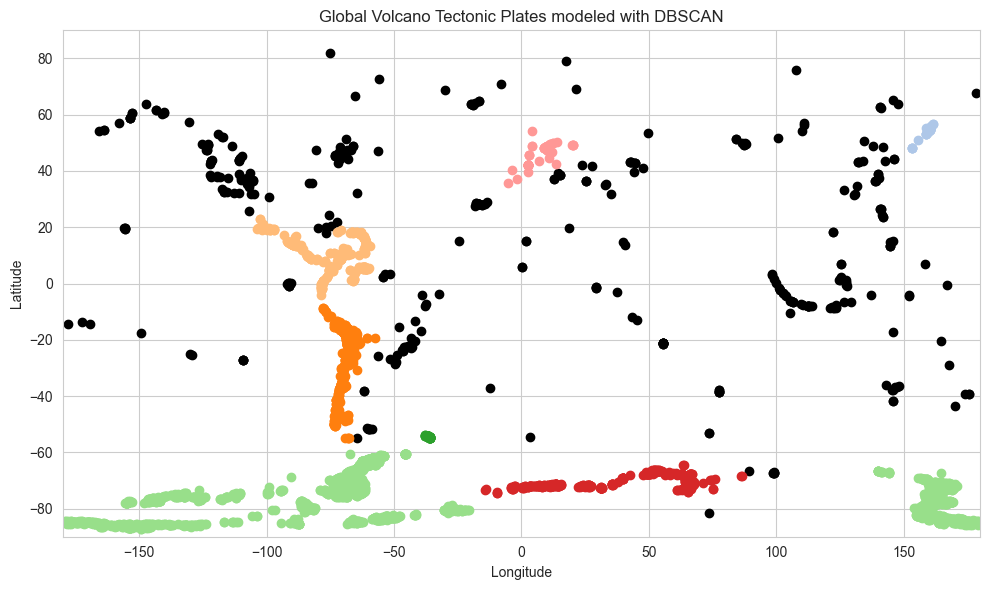

In [28]:
coords = volcanoes_df[['latitude', 'longitude']].to_numpy()
coords_radians = np.radians(coords)

db = DBSCAN(eps=np.radians(5.5), min_samples=20, metric='haversine')
volcanoes_df['cluster'] = db.fit_predict(coords_radians)

print(f"Number of clusters: {len(set(volcanoes_df['cluster'])) - (1 if -1 in volcanoes_df['cluster'] else 0)}")

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

unique_clusters = volcanoes_df['cluster'].unique()
palette = sns.color_palette("tab20", len(unique_clusters))

for cluster_id, color in zip(unique_clusters, palette):
    cluster_data = volcanoes_df[volcanoes_df['cluster'] == cluster_id]
    if cluster_id == -1:
        plt.scatter(cluster_data['longitude'], cluster_data['latitude'],
                    color='black')
    else:
        plt.scatter(cluster_data['longitude'], cluster_data['latitude'],
                    color=color)

plt.title("Global Volcano Tectonic Plates modeled with DBSCAN")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.xlim(-180, 180)
plt.ylim(-90, 90)
plt.tight_layout()
plt.show()

Let's compare the results with KMeans now:

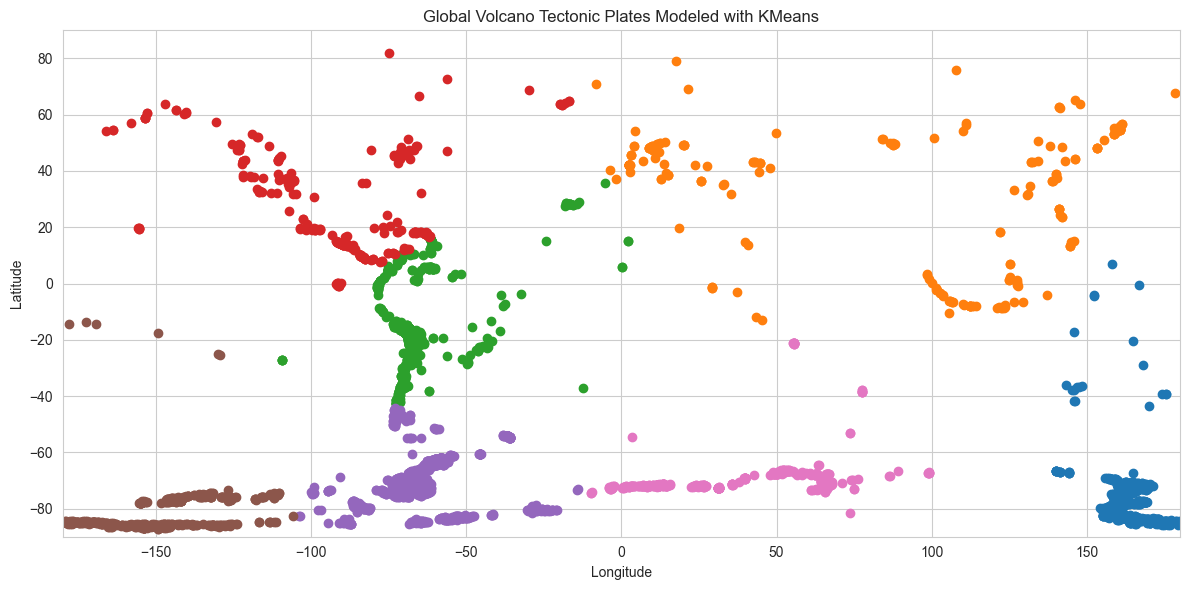

In [ ]:
num_clusters = 7
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
volcanoes_df['cluster'] = kmeans.fit_predict(coords)


plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

unique_clusters = volcanoes_df['cluster'].unique()
palette = sns.color_palette("tab10", len(unique_clusters))

for cluster_id, color in zip(unique_clusters, palette):
    cluster_data = volcanoes_df[volcanoes_df['cluster'] == cluster_id]
    plt.scatter(cluster_data['longitude'], cluster_data['latitude'], color=color)

plt.title("Global Volcano Tectonic Plates Modeled with KMeans")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.xlim(-180, 180)
plt.ylim(-90, 90)
plt.tight_layout()
plt.show()

Looks like KMeans is much better with clusterring in this particular dataset, or DBSCAN needs more fine tuning. In both situations, the conclusion is that clustering can be used to identify volcanoes that lie on the same tectonic plate boundary.